# Pertemuan 6 — Tugas: HDBSCAN pada Dataset Iris

Tugas ini menerapkan HDBSCAN pada dataset nyata dari `sklearn.datasets`, yaitu dataset Iris. Ketentuan tugas:

1. Memilih satu dataset nyata dari `sklearn.datasets` (Iris).
2. Melakukan klasterisasi dengan HDBSCAN.
3. Melaporkan jumlah klaster, banyaknya noise, dan visualisasi (memakai PCA dan t-SNE untuk reduksi dimensi).
4. Menganalisis apakah hasil klasterisasi sesuai dengan label asli dataset.

Sumber: [Tugas](https://polinema.gitbook.io/jti-modul-praktikum-pembelajaran-mesin-2025-2026/js05-klasterisasi-hierarki/tugas).


## 1. Menyiapkan pustaka

Sel berikut memuat pustaka untuk memuat dataset, menjalankan HDBSCAN, mereduksi dimensi, dan menghitung metrik kesesuaian dengan label asli.


In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    adjusted_mutual_info_score,
    homogeneity_score,
    completeness_score,
)
import hdbscan


## 2. Memuat dataset Iris

Dataset Iris berisi 150 data bunga dengan empat fitur ukuran (panjang dan lebar sepal serta petal) dan tiga jenis spesies. Fitur dipakai sebagai masukan model, sedangkan label spesies hanya disimpan untuk mengevaluasi hasil klasterisasi.


In [ ]:
iris = load_iris()
X = iris.data
y = iris.target

print("Ukuran fitur:", X.shape)
print("Nama fitur  :", iris.feature_names)
print("Jumlah label:", len(np.unique(y)))
display(pd.DataFrame(X, columns=iris.feature_names).describe().round(2))


Ukuran fitur: (150, 4)
Nama fitur  : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Jumlah label: 3


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## 3. Klasterisasi dengan HDBSCAN

Model HDBSCAN dijalankan pada empat fitur. Titik yang tidak masuk klaster mana pun diberi label `-1` dan dihitung sebagai noise. Parameter `min_cluster_size` diatur ke `5` mengikuti nilai bawaan pada modul.


In [ ]:
model = hdbscan.HDBSCAN(min_cluster_size=5)
labels = model.fit_predict(X)

n_klaster = len(set(labels[labels != -1]))
n_noise = int((labels == -1).sum())
print(f"Jumlah klaster: {n_klaster}")
print(f"Jumlah noise  : {n_noise}")
sebaran = {int(k): int(v) for k, v in zip(*np.unique(labels, return_counts=True))}
print("Sebaran label :", sebaran)


Jumlah klaster: 2
Jumlah noise  : 0
Sebaran label : {0: 50, 1: 100}


## 4. Visualisasi dengan PCA

PCA mereduksi empat fitur menjadi dua komponen utama. Grafik menampilkan hasil klaster HDBSCAN, dengan titik noise digambar terpisah berwarna hitam.


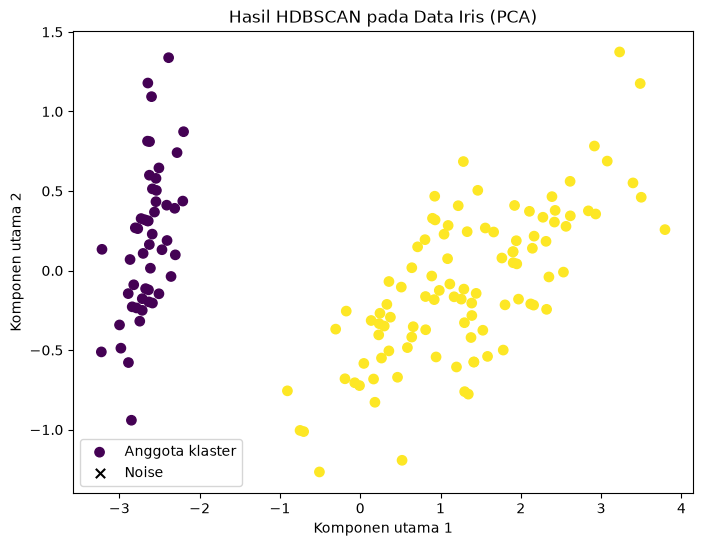

In [ ]:
X_pca = PCA(n_components=2, random_state=0).fit_transform(X)
plt.figure(figsize=(8, 6))
mask = labels != -1
plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=labels[mask], cmap='viridis', s=45, label='Anggota klaster')
plt.scatter(X_pca[~mask, 0], X_pca[~mask, 1], c='black', marker='x', s=45, label='Noise')
plt.xlabel('Komponen utama 1')
plt.ylabel('Komponen utama 2')
plt.title('Hasil HDBSCAN pada Data Iris (PCA)')
plt.legend()
plt.show()


## 5. Visualisasi dengan t-SNE

t-SNE memetakan data ke dua dimensi dengan mempertahankan kedekatan antar titik. Visualisasi ini dipakai sebagai pembanding PCA untuk melihat pemisahan kelompok pada struktur data yang lebih lokal. Proses t-SNE dapat memerlukan waktu lebih lama daripada sel lainnya.


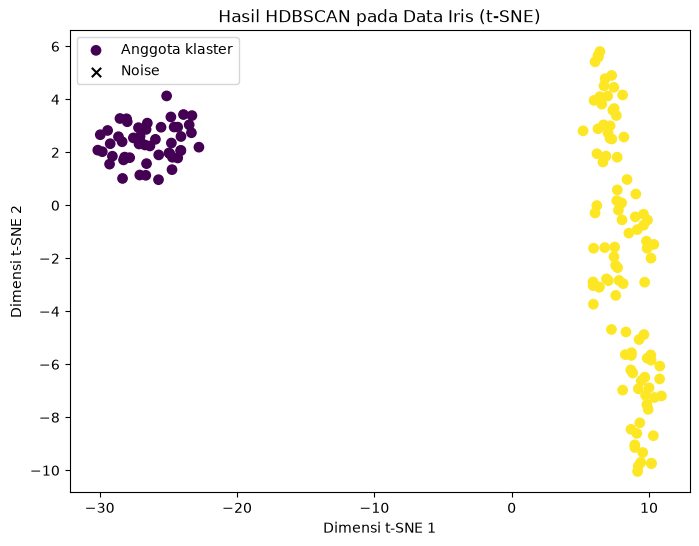

In [ ]:
tsne = TSNE(n_components=2, init='random', random_state=0, learning_rate='auto')
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=labels[mask], cmap='viridis', s=45, label='Anggota klaster')
plt.scatter(X_tsne[~mask, 0], X_tsne[~mask, 1], c='black', marker='x', s=45, label='Noise')
plt.xlabel('Dimensi t-SNE 1')
plt.ylabel('Dimensi t-SNE 2')
plt.title('Hasil HDBSCAN pada Data Iris (t-SNE)')
plt.legend()
plt.show()


## 6. Analisis kesesuaian dengan label asli

Kesesuaian hasil klasterisasi dengan label spesies diukur dengan Adjusted Rand Index (ARI), Adjusted Mutual Information (AMI), homogeneity, dan completeness. Nilai yang mendekati `1` berarti hasil klasterisasi makin sesuai dengan label asli. Tabel silang memperlihatkan sebaran spesies asli pada setiap klaster HDBSCAN, termasuk baris noise.


In [ ]:
ari = adjusted_rand_score(y, labels)
ami = adjusted_mutual_info_score(y, labels)
hom = homogeneity_score(y, labels)
comp = completeness_score(y, labels)

print(f"Adjusted Rand Index   : {ari:.4f}")
print(f"Adjusted Mutual Info  : {ami:.4f}")
print(f"Homogeneity           : {hom:.4f}")
print(f"Completeness          : {comp:.4f}")

tabel = pd.crosstab(pd.Series(iris.target_names[y], name='Spesies asli'),
                    pd.Series(labels, name='Klaster HDBSCAN'))
display(tabel)


Adjusted Rand Index   : 0.5681
Adjusted Mutual Info  : 0.7316
Homogeneity           : 0.5794
Completeness          : 1.0000


Klaster HDBSCAN,0,1
Spesies asli,,
setosa,50,0
versicolor,0,50
virginica,0,50


## 7. Ringkasan hasil

Sel berikut menyusun seluruh nilai evaluasi ke dalam satu tabel agar mudah dibaca.


In [ ]:
ringkasan = pd.DataFrame({
    "Metrik": ["Adjusted Rand Index", "Adjusted Mutual Info", "Homogeneity", "Completeness"],
    "Nilai": [round(ari, 4), round(ami, 4), round(hom, 4), round(comp, 4)],
})
display(ringkasan)


,Metrik,Nilai
0,Adjusted Rand Index,0.5681
1,Adjusted Mutual Info,0.7316
2,Homogeneity,0.5794
3,Completeness,1.0000


## Kesimpulan

HDBSCAN dapat mengelompokkan data Iris tanpa memakai label spesies. Pada percobaan ini terbentuk dua klaster dan tidak ada titik yang ditandai sebagai noise. Satu klaster berisi seluruh spesies setosa, sedangkan versicolor dan virginica tergabung dalam klaster yang sama karena ukuran sepal dan petalnya saling tumpang tindih. Nilai ARI, AMI, homogeneity, dan completeness menunjukkan tingkat kesesuaian hasil klasterisasi dengan label asli, sedangkan visualisasi PCA dan t-SNE memperlihatkan bagaimana kedua klaster tersebut terpisah pada bidang dua dimensi.
